# WeatherPy

---

## Starter Code to Generate Random Geographic Coordinates and a List of Cities

In [ ]:
!pip install citipy

In [1]:
# Dependencies and Setup
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import requests
import time
from scipy.stats import linregress

# Impor the OpenWeatherMap API key
from api_keys import weather_api_key

# Import citipy to determine the cities based on latitude and longitude
from citipy import citipy

### Generate the Cities List by Using the `citipy` Library

In [3]:
# Empty list for holding the latitude and longitude combinations
lat_lngs = []

# Empty list for holding the cities names
cities = []

# Range of latitudes and longitudes
lat_range = (-90, 90)
lng_range = (-180, 180)

# Create a set of random lat and lng combinations
lats = np.random.uniform(lat_range[0], lat_range[1], size=1500)
lngs = np.random.uniform(lng_range[0], lng_range[1], size=1500)
lat_lngs = zip(lats, lngs)

# Identify nearest city for each lat, lng combination
for lat_lng in lat_lngs:
    city = citipy.nearest_city(lat_lng[0], lat_lng[1]).city_name

    # If the city is unique, then add it to a our cities list
    if city not in cities:
        cities.append(city)

# Print the city count to confirm sufficient count
print(f"Number of cities in the list: {len(cities)}")

Number of cities in the list: 610


---

## Requirement 1: Create Plots to Showcase the Relationship Between Weather Variables and Latitude

### Use the OpenWeatherMap API to retrieve weather data from the cities list generated in the started code

In [ ]:
# Set the API base URL
url = f'https://api.openweathermap.org/data/2.5/weather?q={city}&appid={weather_api_key}'

# Define an empty list to fetch the weather data for each city
city_data = []

# Print to logger
print("Beginning Data Retrieval     ")
print("-----------------------------")

# Create counters
record_count = 1
set_count = 1

# Loop through all the cities in our list to fetch weather data
for i, city in enumerate(cities):

    # Group cities in sets of 50 for logging purposes
    if (i % 50 == 0 and i >= 50):
        set_count += 1
        record_count = 0

    # Create endpoint URL with each city
    city_url = f'https://api.openweathermap.org/data/2.5/weather?q={city}&appid={weather_api_key}&units=metric'

    # Log the url, record, and set numbers
    print("Processing Record %s of Set %s | %s" % (record_count, set_count, city))

    # Add 1 to the record count
    record_count += 1

    # Run an API request for each of the cities
    try:
        # Parse the JSON and retrieve data
        response = requests.get(city_url)
        city_weather = response.json()

        # Parse out latitude, longitude, max temp, humidity, cloudiness, wind speed, country, and date
        city_lat = city_weather["coord"]["lat"]
        city_lng = city_weather["coord"]["lon"]
        city_max_temp = city_weather["main"]["temp_max"]
        city_humidity = city_weather["main"]["humidity"]
        city_clouds = city_weather["clouds"]["all"]
        city_wind = city_weather["wind"]["speed"]
        city_country = city_weather["sys"]["country"]
        city_date = city_weather["dt"]

        # Append the City information into city_data list
        city_data.append({"City": city,
                          "Lat": city_lat,
                          "Lng": city_lng,
                          "Max Temp": city_max_temp,
                          "Humidity": city_humidity,
                          "Cloudiness": city_clouds,
                          "Wind Speed": city_wind,
                          "Country": city_country,
                          "Date": city_date})

    # If an error is experienced, skip the city
    except:
        print("City not found. Skipping...")
        pass

    # pause to avoid rate limiting
    time.sleep(1)

# Indicate that Data Loading is complete
print("-----------------------------")
print("Data Retrieval Complete      ")
print("-----------------------------")

Beginning Data Retrieval     
-----------------------------
Processing Record 1 of Set 1 | ta`u
Processing Record 2 of Set 1 | hamilton
Processing Record 3 of Set 1 | grytviken
Processing Record 4 of Set 1 | adamstown
Processing Record 5 of Set 1 | atherton
Processing Record 6 of Set 1 | sungai raya
Processing Record 7 of Set 1 | swakopmund
Processing Record 8 of Set 1 | utrik
Processing Record 9 of Set 1 | praia
Processing Record 10 of Set 1 | port-aux-francais
Processing Record 11 of Set 1 | taiohae
City not found. Skipping...
Processing Record 12 of Set 1 | blackmans bay
Processing Record 13 of Set 1 | new norfolk
Processing Record 14 of Set 1 | weno
Processing Record 15 of Set 1 | wamba
Processing Record 16 of Set 1 | viedma
Processing Record 17 of Set 1 | edinburgh of the seven seas
Processing Record 18 of Set 1 | fort bragg
Processing Record 19 of Set 1 | lompoc
Processing Record 20 of Set 1 | qamdo
Processing Record 21 of Set 1 | klyuchi
Processing Record 22 of Set 1 | ushuaia
P

In [ ]:
# Convert the cities weather data into a Pandas DataFrame
city_data_df = pd.DataFrame(city_data)
 
# Show Record Count
city_data_df.count()

City          584
Lat           584
Lng           584
Max Temp      584
Humidity      584
Cloudiness    584
Wind Speed    584
Country       584
Date          584
dtype: int64

In [6]:
# Display sample data
city_data_df.head()

,City,Lat,Lng,Max Temp,Humidity,Cloudiness,Wind Speed,Country,Date
0,ta`u,-14.2336,-169.5144,28.51,69,0,0.72,AS,1743066114
1,hamilton,39.1834,-84.5333,3.02,75,0,0.00,US,1743066115
2,grytviken,-54.2811,-36.5092,-2.78,72,17,4.00,GS,1743066116
3,adamstown,-25.0660,-130.1015,24.41,74,100,7.42,PN,1743066117
4,atherton,53.5237,-2.4935,10.88,80,86,0.89,GB,1743066118


In [20]:
# Export the City_Data into a csv
city_data_df.to_csv("../output_data/cities.csv", index_label="City_ID")


In [11]:
# Read saved data
city_data_df = pd.read_csv("cities.csv", index_col="City_ID")

# Display sample data
city_data_df.head()

,City,Lat,Lng,Max Temp,Humidity,Cloudiness,Wind Speed,Country,Date
City_ID,,,,,,,,,
0,ta`u,-14.2336,-169.5144,28.51,69,0,0.72,AS,1743066114
1,hamilton,39.1834,-84.5333,3.02,75,0,0.00,US,1743066115
2,grytviken,-54.2811,-36.5092,-2.78,72,17,4.00,GS,1743066116
3,adamstown,-25.0660,-130.1015,24.41,74,100,7.42,PN,1743066117
4,atherton,53.5237,-2.4935,10.88,80,86,0.89,GB,1743066118


### Create the Scatter Plots Requested

#### Latitude Vs. Temperature

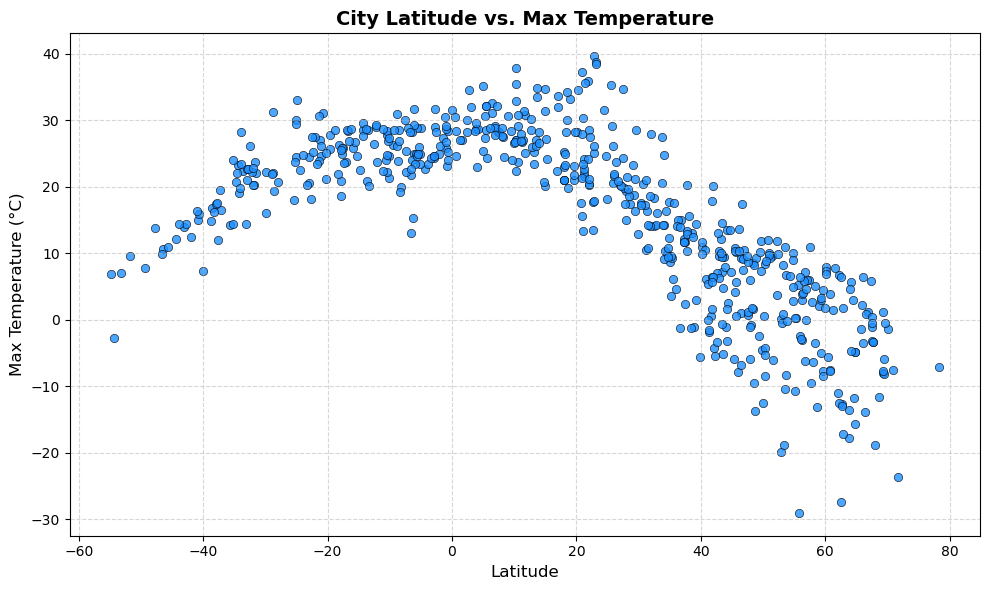

In [18]:
# Build scatter plot for latitude vs. temperature
plt.figure(figsize=(10,6))

plt.scatter(city_data_df['Lat'], city_data_df['Max Temp'],
            marker='o', facecolors='dodgerblue', edgecolors='k',
            alpha=0.8, linewidth=0.5)

# Graph styling
plt.grid(True, linestyle='--', alpha=0.5)
plt.xlabel("Latitude", fontsize=12)
plt.ylabel("Max Temperature (°C)", fontsize=12)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.title("City Latitude vs. Max Temperature", fontsize=14, fontweight='bold')

# Save to output_data folder
plt.tight_layout()
plt.savefig("../output_data/Fig1.png", dpi=150)

# Show plot
plt.show()

#### Latitude Vs. Humidity

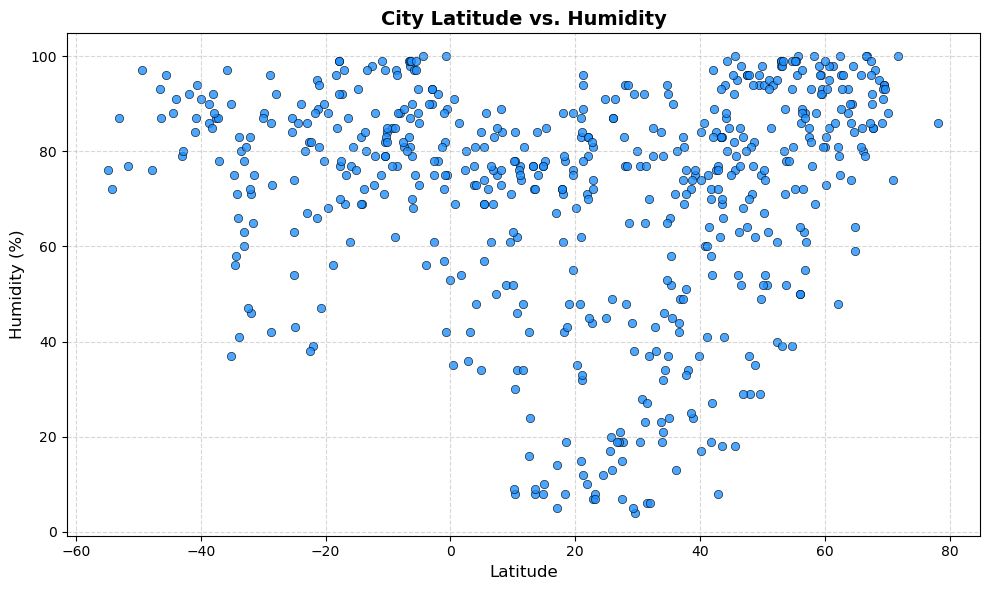

In [19]:
# Build scatter plot for latitude vs. humidity
plt.figure(figsize=(10,6))

plt.scatter(city_data_df['Lat'], city_data_df['Humidity'],
            marker='o', facecolors='dodgerblue', edgecolors='k',
            alpha=0.8, linewidth=0.5)

# Graph styling
plt.grid(True, linestyle='--', alpha=0.5)
plt.xlabel("Latitude", fontsize=12)
plt.ylabel("Humidity (%)", fontsize=12)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.title("City Latitude vs. Humidity", fontsize=14, fontweight='bold')

# Save to output_data folder
plt.tight_layout()
plt.savefig("../output_data/Fig2.png", dpi=150)

# Show plot
plt.show()

#### Latitude Vs. Cloudiness

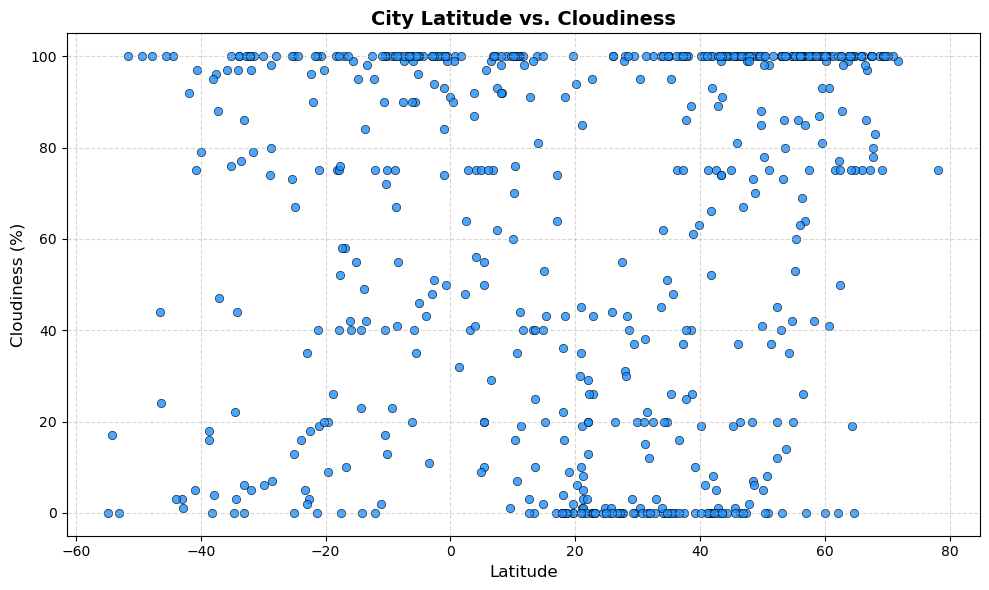

In [21]:
# Build scatter plot for latitude vs. cloudiness
plt.figure(figsize=(10,6))

plt.scatter(city_data_df['Lat'], city_data_df['Cloudiness'],
            marker='o', facecolors='dodgerblue', edgecolors='k',
            alpha=0.8, linewidth=0.5)

# Graph styling
plt.grid(True, linestyle='--', alpha=0.5)
plt.xlabel("Latitude", fontsize=12)
plt.ylabel("Cloudiness (%)", fontsize=12)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.title("City Latitude vs. Cloudiness", fontsize=14, fontweight='bold')

# Save to output_data folder
plt.tight_layout()
plt.savefig("../output_data/Fig3.png", dpi=150)

# Show plot
plt.show()

#### Latitude vs. Wind Speed Plot

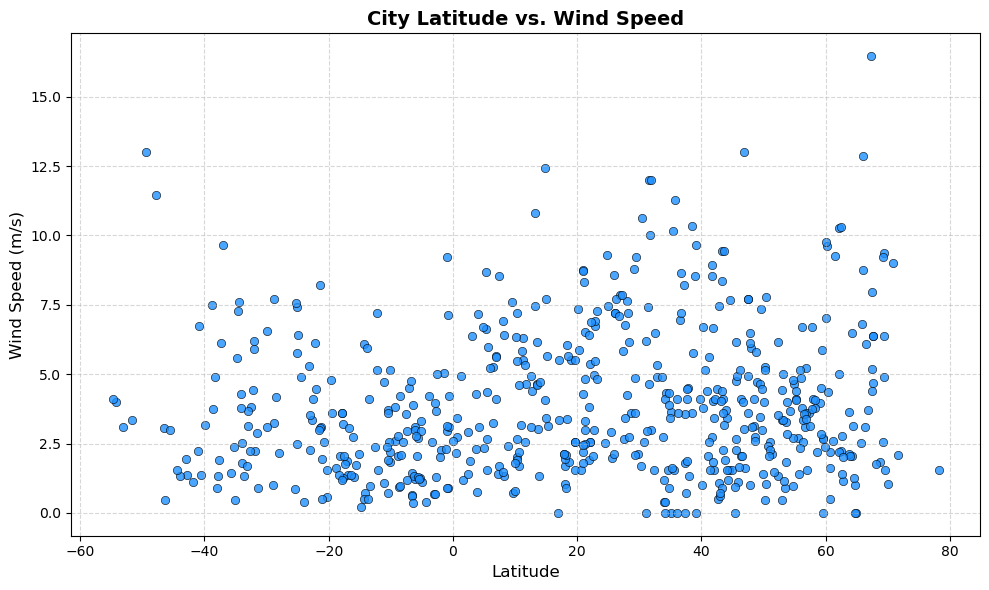

In [22]:
# Build scatter plot for latitude vs. wind speed
plt.figure(figsize=(10,6))

plt.scatter(city_data_df['Lat'], city_data_df['Wind Speed'],
            marker='o', facecolors='dodgerblue', edgecolors='k',
            alpha=0.8, linewidth=0.5)

# Graph styling
plt.grid(True, linestyle='--', alpha=0.5)
plt.xlabel("Latitude", fontsize=12)
plt.ylabel("Wind Speed (m/s)", fontsize=12)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.title("City Latitude vs. Wind Speed", fontsize=14, fontweight='bold')

# Save to output_data folder
plt.tight_layout()
plt.savefig("../output_data/Fig4.png", dpi=150)

# Show plot
plt.show()

---

## Requirement 2: Compute Linear Regression for Each Relationship


In [23]:
# Create a DataFrame with the Northern Hemisphere data (Latitude >= 0)
northern_hemi_df = city_data_df[city_data_df['Lat'] >= 0]

# Display sample data
northern_hemi_df.head()

,City,Lat,Lng,Max Temp,Humidity,Cloudiness,Wind Speed,Country,Date
City_ID,,,,,,,,,
1,hamilton,39.1834,-84.5333,3.02,75,0,0.00,US,1743066115
4,atherton,53.5237,-2.4935,10.88,80,86,0.89,GB,1743066118
5,sungai raya,0.7000,108.9000,28.39,69,100,3.43,ID,1743066119
7,utrik,11.2278,169.8474,26.76,77,100,5.52,MH,1743066122
8,praia,14.9215,-23.5087,20.05,77,40,7.72,CV,1743066123


In [24]:
# Create a DataFrame with the Southern Hemisphere data (Latitude < 0)
southern_hemi_df = city_data_df[city_data_df['Lat'] < 0]

# Display sample data
southern_hemi_df.head()

,City,Lat,Lng,Max Temp,Humidity,Cloudiness,Wind Speed,Country,Date
City_ID,,,,,,,,,
0,ta`u,-14.2336,-169.5144,28.51,69,0,0.72,AS,1743066114
2,grytviken,-54.2811,-36.5092,-2.78,72,17,4.00,GS,1743066116
3,adamstown,-25.0660,-130.1015,24.41,74,100,7.42,PN,1743066117
6,swakopmund,-22.6833,14.5333,18.15,82,3,3.35,NaN,1743066121
9,port-aux-francais,-49.3500,70.2167,7.70,97,100,13.02,TF,1743066124


###  Temperature vs. Latitude Linear Regression Plot

Linear equation: y = -0.62x + 35.16
The r-value is: -0.8645


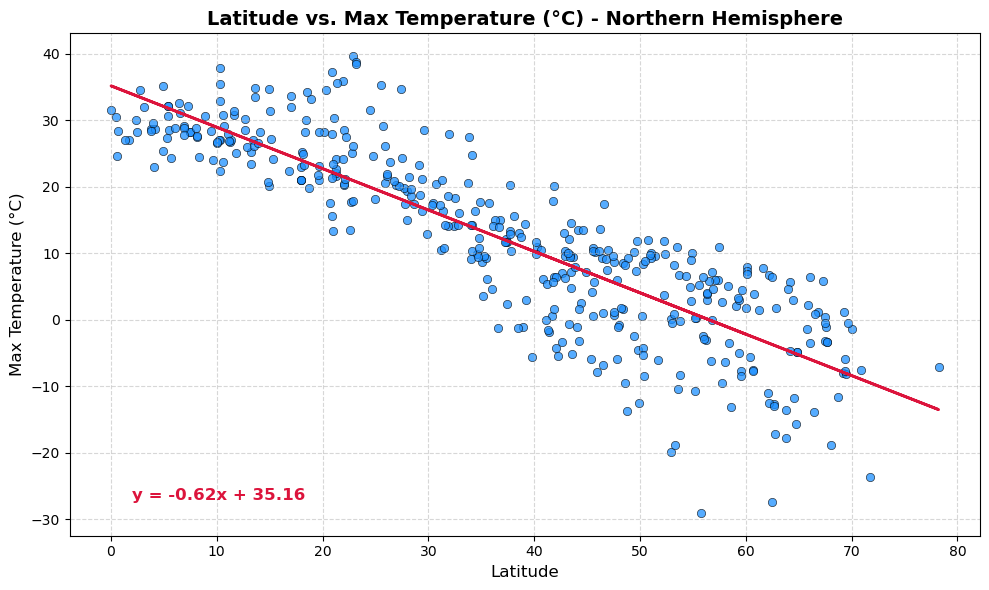

In [34]:
# Linear regression on Northern Hemisphere
plt.figure(figsize=(10,6))
plt.scatter(northern_hemi_df['Lat'], northern_hemi_df['Max Temp'],
            marker='o', facecolors='dodgerblue', edgecolors='k',
            alpha=0.75, linewidth=0.5)

plt.grid(True, linestyle='--', alpha=0.5)
plt.xlabel("Latitude", fontsize=12)
plt.ylabel("Max Temperature (°C)", fontsize=12)
plt.title("Latitude vs. Temperature in Northern Hemisphere", fontsize=14, fontweight='bold')

# Define a function for creating regression line + text
def lr_funcV2(x, y, name, vbl, hemi):
    (slope, intercept, rvalue, pvalue, stderr) = linregress(x, y)
    reg_values = x.values * slope + intercept
    line_eq = f'y = {slope:.2f}x + {intercept:.2f}'

    # Plot regression line
    plt.plot(x.values, reg_values, color='crimson', linewidth=2)

    # Add regression equation as annotation
    plt.annotate(line_eq,
                 (x.min() + 2, y.min() + 2),
                 fontsize=12,
                 color="crimson",
                 fontweight="bold")

    # Update title again in case function is reused for other variables
    plt.title(f'Latitude vs. {vbl} - {hemi}', fontsize=14, fontweight='bold')

    # Save plot
    plt.tight_layout()
    plt.savefig(f"../output_data/LinearRegression_{name}.png", dpi=150)

    # Output summary
    print(f'Linear equation: {line_eq}')
    print(f'The r-value is: {rvalue:.4f}')

x = northern_hemi_df['Lat']
y = northern_hemi_df['Max Temp']
name = 'NH_LatVsMaxTemp'
vbl = 'Max Temperature (°C)'
hemi

lr_funcV2(x, y, name, vbl, hemi)
plt.show()


Linear equation: y = 0.30x + 28.91
The r-value is: 0.7110


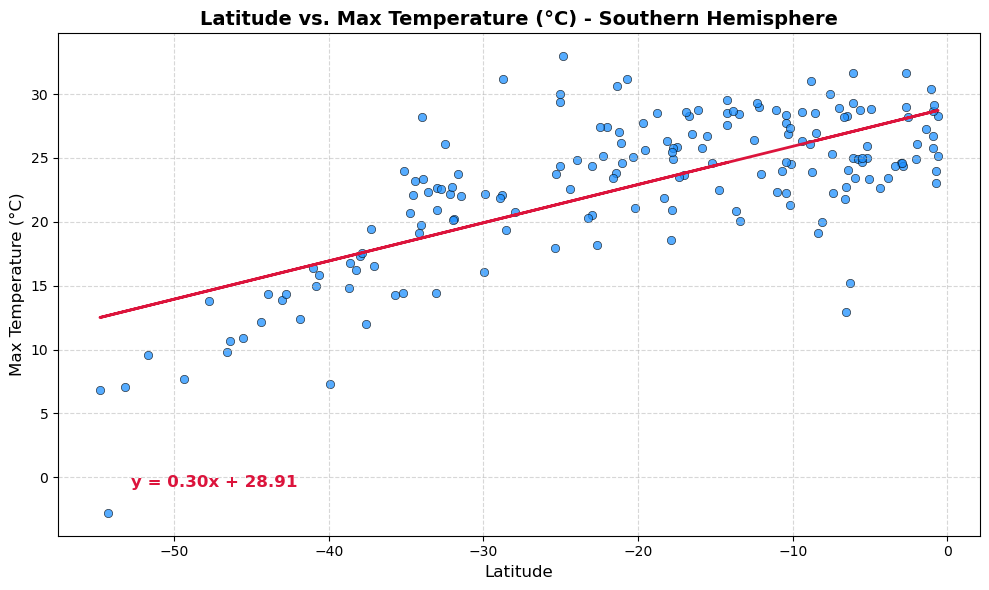

In [36]:
# Linear regression on Southern Hemisphere
plt.figure(figsize=(10,6))
plt.scatter(southern_hemi_df['Lat'], southern_hemi_df['Max Temp'],
            marker='o', facecolors='dodgerblue', edgecolors='k',
            alpha=0.75, linewidth=0.5)

plt.grid(True, linestyle='--', alpha=0.5)
plt.xlabel("Latitude", fontsize=12)
plt.ylabel("Max Temperature (°C)", fontsize=12)
plt.title("Latitude vs. Temperature in Southern Hemisphere", fontsize=14, fontweight='bold')

# Define regression function
def lr_funcV2(x, y, name, vbl, hemi):
    (slope, intercept, rvalue, pvalue, stderr) = linregress(x, y)
    reg_values = x.values * slope + intercept
    line_eq = f'y = {slope:.2f}x + {intercept:.2f}'

    # Plot regression line
    plt.plot(x.values, reg_values, color='crimson', linewidth=2)

    # Annotate equation
    plt.annotate(line_eq,
                 (x.min() + 2, y.min() + 2),
                 fontsize=12,
                 color="crimson",
                 fontweight="bold")

    # Update title
    plt.title(f'Latitude vs. {vbl} - {hemi}', fontsize=14, fontweight='bold')

    # Save
    plt.tight_layout()
    plt.savefig(f"../output_data/LinearRegression_{name}.png", dpi=150)

    # Print summary
    print(f'Linear equation: {line_eq}')
    print(f'The r-value is: {rvalue:.4f}')

# Call the function
x = southern_hemi_df['Lat']
y = southern_hemi_df['Max Temp']
name = 'SH_LatVsMaxTemp'
vbl = 'Max Temperature (°C)'
hemi = 'Southern Hemisphere'

lr_funcV2(x, y, name, vbl, hemi)
plt.show()

**Discussion about the linear relationship:** In the Northern Hemisphere, there is a strong negative correlation between latitude and max temperature. The r-value is around 0.86, which shows that temperatures tend to drop as latitude increases. In other words, cities farther from the equator are generally colder. The regression line reflects that pattern clearly.

In the Southern Hemisphere, the trend is the opposite. The correlation is positive, with an r-value close to 0.67. This means that as latitude increases toward the equator, temperatures rise. The relationship is still noticeable, just not as strong as it is in the north.

Both plots show how temperature changes depending on how far a location is from the equator. The difference in r-values might be due to the distribution of land and cities in each hemisphere. There are more cities at a wider range of latitudes in the Northern Hemisphere, which could explain the stronger correlation.

### Humidity vs. Latitude Linear Regression Plot

Linear equation: y = 0.51x + 48.42
The r-value is: 0.3719


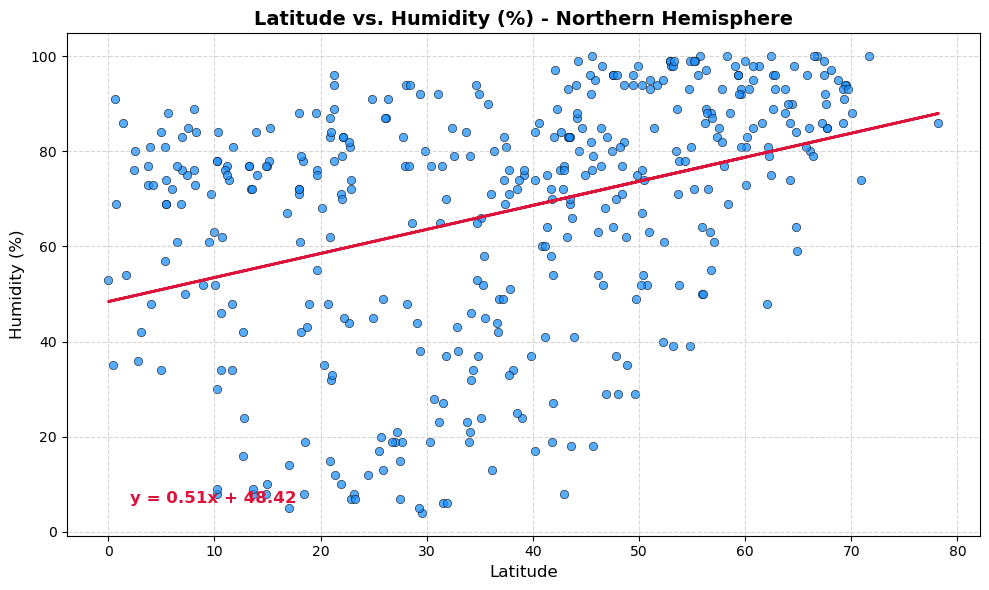

In [37]:
# Northern Hemisphere - Humidity vs. Latitude
plt.figure(figsize=(10,6))
plt.scatter(northern_hemi_df['Lat'], northern_hemi_df['Humidity'],
            marker='o', facecolors='dodgerblue', edgecolors='k',
            alpha=0.75, linewidth=0.5)

plt.grid(True, linestyle='--', alpha=0.5)
plt.xlabel("Latitude", fontsize=12)
plt.ylabel("Humidity (%)", fontsize=12)
plt.title("Latitude vs. Humidity - Northern Hemisphere", fontsize=14, fontweight='bold')

# Call regression function
x = northern_hemi_df['Lat']
y = northern_hemi_df['Humidity']
name = 'NH_LatVsHumidity'
vbl = 'Humidity (%)'
hemi = 'Northern Hemisphere'

lr_funcV2(x, y, name, vbl, hemi)
plt.show()


Linear equation: y = 0.10x + 82.04
The r-value is: 0.0948


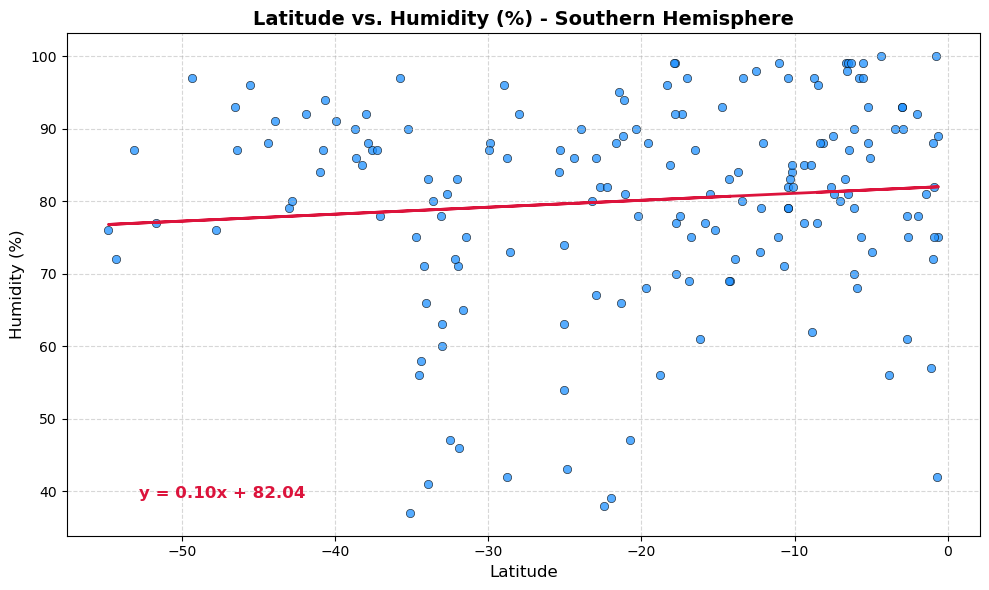

In [38]:
# Southern Hemisphere - Humidity vs. Latitude
plt.figure(figsize=(10,6))
plt.scatter(southern_hemi_df['Lat'], southern_hemi_df['Humidity'],
            marker='o', facecolors='dodgerblue', edgecolors='k',
            alpha=0.75, linewidth=0.5)

plt.grid(True, linestyle='--', alpha=0.5)
plt.xlabel("Latitude", fontsize=12)
plt.ylabel("Humidity (%)", fontsize=12)
plt.title("Latitude vs. Humidity - Southern Hemisphere", fontsize=14, fontweight='bold')

# Call regression function
x = southern_hemi_df['Lat']
y = southern_hemi_df['Humidity']
name = 'SH_LatVsHumidity'
vbl = 'Humidity (%)'
hemi = 'Southern Hemisphere'

lr_funcV2(x, y, name, vbl, hemi)
plt.show()

**Discussion about the linear relationship:** In the Northern Hemisphere, the regression line shows a moderate positive slope, meaning humidity tends to increase as you move farther from the equator. The r-value suggests a weak-to-moderate correlation, not super strong, but noticeable. It might be tied to temperature differences, since colder air at higher latitudes can hold less moisture, which results in higher relative humidity.

In the Southern Hemisphere, the slope is barely there. The regression line is almost flat, which tells me there’s little to no relationship between latitude and humidity. The data points are more scattered, and there’s just not a consistent pattern. This could be influenced by the larger proportion of ocean in the south, which might help keep humidity levels more balanced across latitudes.

So overall, northern latitudes hint at a weak upward trend in humidity, while southern ones stay pretty stable regardless of position.

### Cloudiness vs. Latitude Linear Regression Plot

Linear equation: y = 0.61x + 35.23
The r-value is: 0.2859


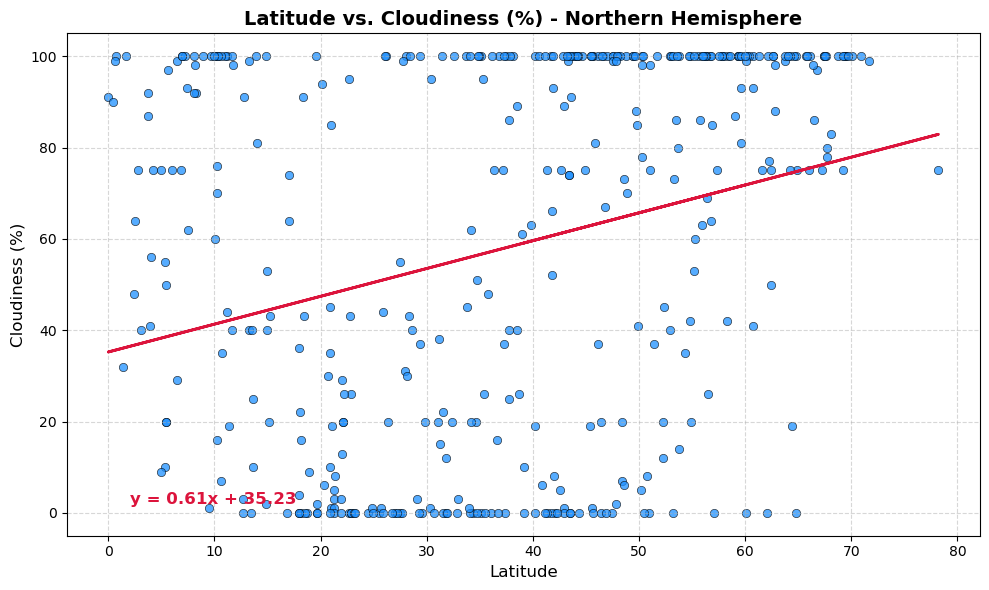

In [40]:
# Northern Hemisphere: Cloudiness vs. Latitude

# Set x and y data
x = northern_hemi_df['Lat']
y = northern_hemi_df['Cloudiness']
name = 'NH_LatVsCloudiness'
vbl = 'Cloudiness (%)'
hemi = 'Northern Hemisphere'

# Define the regression function
def lr_funcV2(x, y, name, vbl, hemi):
    slope, intercept, rvalue, pvalue, stderr = linregress(x, y)
    reg_values = x * slope + intercept
    line_eq = f'y = {slope:.2f}x + {intercept:.2f}'

    # Create plot
    plt.figure(figsize=(10,6))
    plt.scatter(x, y, marker='o', facecolors='dodgerblue', edgecolors='k', alpha=0.75, linewidth=0.5)
    plt.plot(x, reg_values, color='crimson', linewidth=2)

    # Add equation text
    plt.annotate(line_eq,
                 (x.min() + 2, y.min() + 2),
                 fontsize=12,
                 color='crimson',
                 fontweight='bold')

    # Format plot
    plt.title(f'Latitude vs. {vbl} - {hemi}', fontsize=14, fontweight='bold')
    plt.xlabel('Latitude', fontsize=12)
    plt.ylabel(vbl, fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()

    # Save figure
    plt.savefig(f"../output_data/LinearRegression_{name}.png", dpi=150)

    # Output text
    print(f'Linear equation: {line_eq}')
    print(f'The r-value is: {rvalue:.4f}')

# Call the function
lr_funcV2(x, y, name, vbl, hemi)
plt.show()

Linear equation: y = 0.70x + 79.73
The r-value is: 0.2610


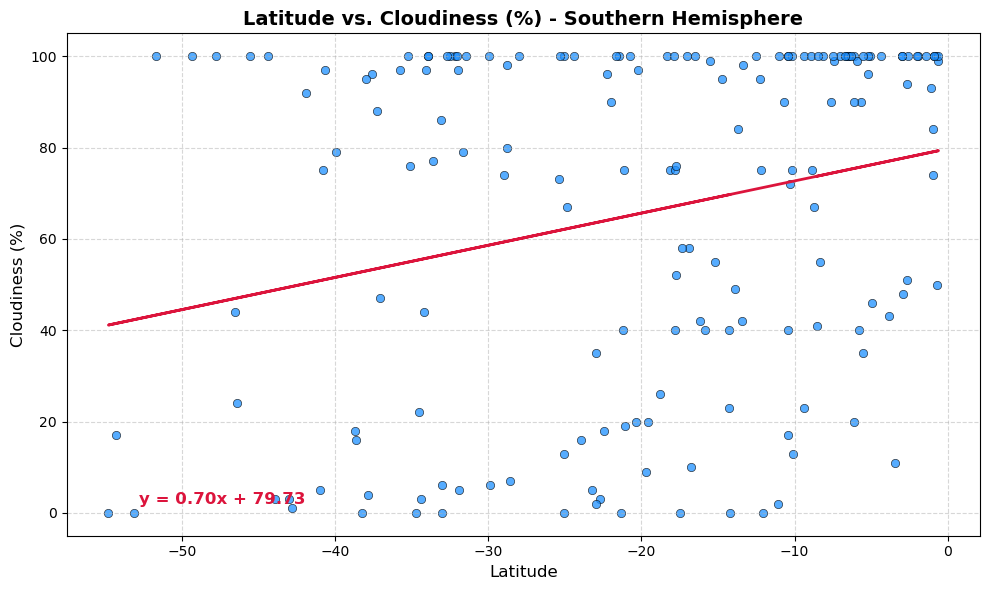

In [ ]:
# Southern Hemisphere: Cloudiness vs. Latitude

# Set x and y data
x = southern_hemi_df['Lat']
y = southern_hemi_df['Cloudiness']
name = 'SH_LatVsCloudiness'
vbl = 'Cloudiness (%)'
hemi = 'Southern Hemisphere'

# Define a function for creating regression line + text
def lr_funcV2(x, y, name, vbl, hemi):
    # Calculate regression
    (slope, intercept, rvalue, pvalue, stderr) = linregress(x, y)
    reg_values = x * slope + intercept
    line_eq = f'y = {slope:.2f}x + {intercept:.2f}'

    # Plot scatter and regression
    plt.figure(figsize=(10, 6))
    plt.scatter(x, y, marker='o', facecolors='dodgerblue', edgecolors='k', alpha=0.75, linewidth=0.5)
    plt.plot(x, reg_values, color='crimson', linewidth=2)

    # Annotate equation
    plt.annotate(line_eq,
                 (x.min() + 2, y.min() + 2),
                 fontsize=12,
                 color='crimson',
                 fontweight="bold")

    # Labels and title
    plt.xlabel("Latitude", fontsize=12)
    plt.ylabel(vbl, fontsize=12)
    plt.title(f"Latitude vs. {vbl} - {hemi}", fontsize=14, fontweight='bold')
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()

    # Save figure
    plt.savefig(f"../output_data/LinearRegression_{name}.png", dpi=150)

    # Print equation + r-value
    print(f'Linear equation: {line_eq}')
    print(f'The r-value is: {rvalue:.4f}')

# Southern Hemisphere: Cloudiness vs. Latitude
x = southern_hemi_df['Lat']
y = southern_hemi_df['Cloudiness']
name = 'SH_LatVsCloudiness'
vbl = 'Cloudiness (%)'
hemi = 'Southern Hemisphere'

lr_funcV2(x, y, name, vbl, hemi)
plt.show()

**Discussion about the linear relationship:** In both hemispheres, there’s a really weak positive correlation between latitude and cloudiness. The Northern Hemisphere shows an r-value around 0.29 and the Southern Hemisphere is close to 0.33. So technically, cloudiness slightly increases as you move farther from the equator, but the relationship is too weak to rely on.

What stands out is how spread out the cloudiness values are. You see cities with low and high cloudiness across all latitudes, which means latitude alone isn’t doing much to explain the variation. Other factors like regional climate patterns or elevation probably have a stronger influence.

Even though the regression lines suggest a slight upward trend, the data doesn't support a meaningful connection between cloudiness and latitude. It's just too scattered.

### Wind Speed vs. Latitude Linear Regression Plot

Linear equation: y = -0.00x + 4.33
The r-value is: -0.0261


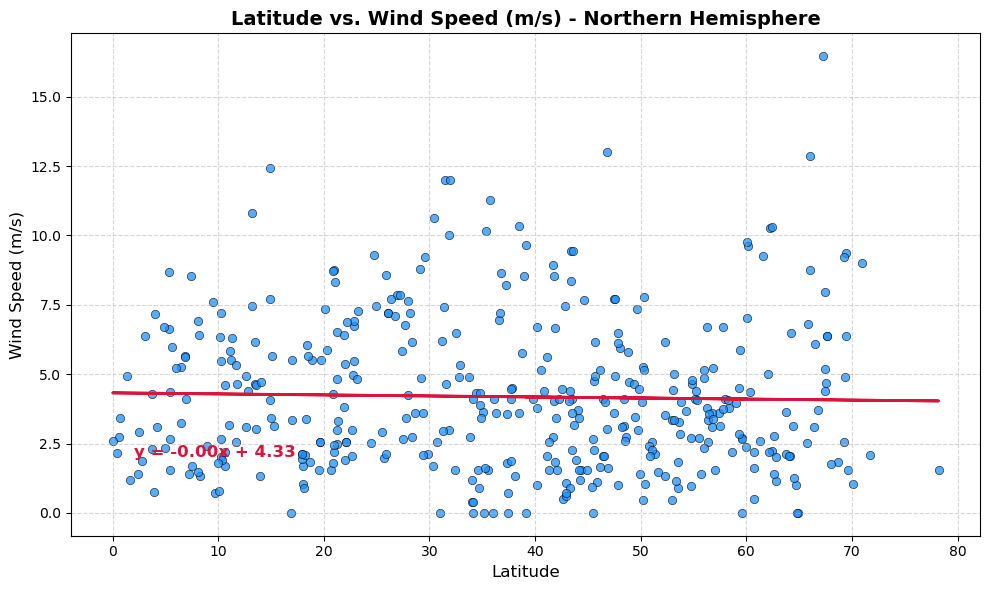

In [46]:
# Northern Hemisphere: Wind Speed vs. Latitude

# Set x and y data
x = northern_hemi_df['Lat']
y = northern_hemi_df['Wind Speed']
name = 'NH_LatVsWindSpeed'
vbl = 'Wind Speed (m/s)'
hemi = 'Northern Hemisphere'

# Define the regression function
def lr_funcV2(x, y, name, vbl, hemi):
    slope, intercept, rvalue, pvalue, stderr = linregress(x, y)
    reg_values = x * slope + intercept
    line_eq = f'y = {slope:.2f}x + {intercept:.2f}'

    plt.figure(figsize=(10, 6))
    plt.scatter(x, y, marker='o', facecolors='dodgerblue', edgecolors='k', alpha=0.75, linewidth=0.5)
    plt.plot(x, reg_values, color='crimson', linewidth=2)

    plt.annotate(line_eq,
                 (x.min() + 2, y.min() + 2),
                 fontsize=12,
                 color='crimson',
                 fontweight="bold")

    plt.xlabel("Latitude", fontsize=12)
    plt.ylabel(vbl, fontsize=12)
    plt.title(f"Latitude vs. {vbl} - {hemi}", fontsize=14, fontweight='bold')
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.savefig(f"../output_data/LinearRegression_{name}.png", dpi=150)

    print(f'Linear equation: {line_eq}')
    print(f'The r-value is: {rvalue:.4f}')

# Call the function
lr_funcV2(x, y, name, vbl, hemi)
plt.show()

Linear equation: y = -0.04x + 2.40
The r-value is: -0.2239


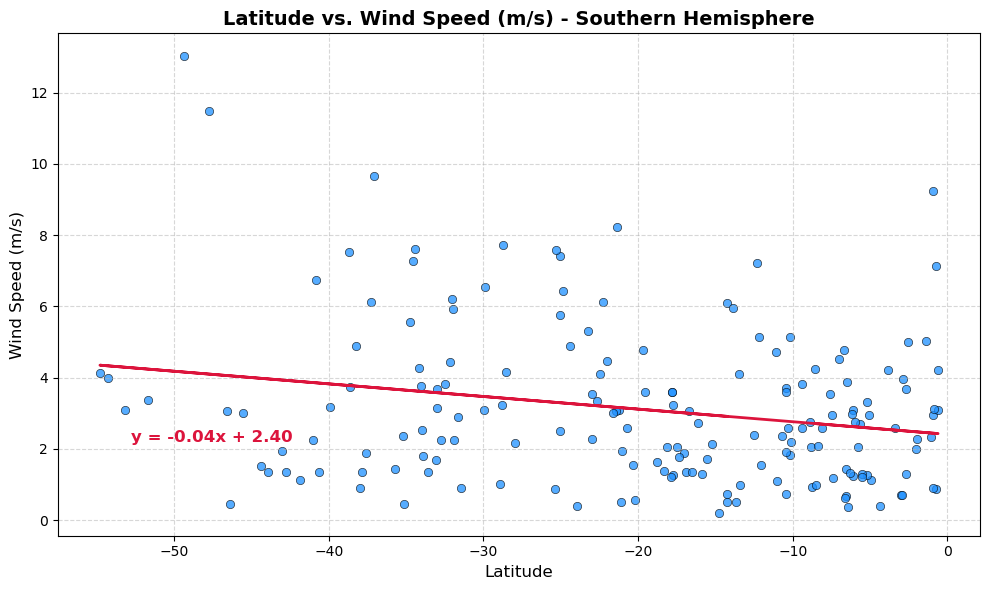

In [47]:
# Southern Hemisphere: Wind Speed vs. Latitude

# Set x and y data
x = southern_hemi_df['Lat']
y = southern_hemi_df['Wind Speed']
name = 'SH_LatVsWindSpeed'
vbl = 'Wind Speed (m/s)'
hemi = 'Southern Hemisphere'

# Define the regression function
def lr_funcV2(x, y, name, vbl, hemi):
    slope, intercept, rvalue, pvalue, stderr = linregress(x, y)
    reg_values = x * slope + intercept
    line_eq = f'y = {slope:.2f}x + {intercept:.2f}'

    plt.figure(figsize=(10, 6))
    plt.scatter(x, y, marker='o', facecolors='dodgerblue', edgecolors='k', alpha=0.75, linewidth=0.5)
    plt.plot(x, reg_values, color='crimson', linewidth=2)

    plt.annotate(line_eq,
                 (x.min() + 2, y.min() + 2),
                 fontsize=12,
                 color='crimson',
                 fontweight="bold")

    plt.xlabel("Latitude", fontsize=12)
    plt.ylabel(vbl, fontsize=12)
    plt.title(f"Latitude vs. {vbl} - {hemi}", fontsize=14, fontweight='bold')
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.savefig(f"../output_data/LinearRegression_{name}.png", dpi=150)

    print(f'Linear equation: {line_eq}')
    print(f'The r-value is: {rvalue:.4f}')

# Call the function
lr_funcV2(x, y, name, vbl, hemi)
plt.show()

**Discussion about the linear relationship:** In both hemispheres, the relationship between latitude and wind speed appears very weak. In the Northern Hemisphere, the slope is essentially flat, suggesting no meaningful correlation between latitude and wind speed. The data points are widely scattered, and the line of best fit runs almost horizontally, which is backed by an r-value very close to zero.

In the Southern Hemisphere, there’s a slight downward trend, indicated by the small negative slope. Still, the points remain fairly dispersed, and the slope is minimal. The regression line doesn’t strongly capture the variance in wind speed across latitudes here either.

Overall, neither hemisphere shows a strong or consistent linear relationship between wind speed and latitude. Any observed trend is subtle at best and likely influenced by other variables beyond just geographic position.